## In This Dataset I Am Analyzing The Retail Sales and Most Benefitable Products Region Wise

## Objectives
#### . Total City Wise sales
#### . Find The Top 5 cities In Sales
#### . Find The Top Cities In Profits
#### . Find The Loss Cities In Sales
#### . Find The Loss Cities In Profits
#### . Sales By Cateogoy Wise High And Low 


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## step 3 load datase


In [2]:
df=pd.read_csv("SampleSuperstore.csv.zip")

## step 3 understand dataset

In [3]:
df.shape

(9994, 13)

In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.sample(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
6247,Standard Class,Consumer,United States,Columbus,Indiana,47201,Central,Office Supplies,Binders,43.410,1,0.0,19.9686
6812,First Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Office Supplies,Binders,18.312,4,0.7,-12.2080
1893,Standard Class,Consumer,United States,Medford,Oregon,97504,West,Office Supplies,Paper,24.784,1,0.2,7.7450
6417,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Fasteners,5.984,2,0.2,-1.3464
2646,Second Class,Consumer,United States,Tulsa,Oklahoma,74133,Central,Office Supplies,Binders,42.810,3,0.0,20.1207


In [6]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [7]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [9]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

#### . There Is No Null Values Found In This Dataset

## step 4 Identify columns data type

#### thats is categorical columns

In [11]:
categorical_cols=df.select_dtypes(include=("object")).columns
print("Categorical columns")
print(categorical_cols)

Categorical columns
Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
       'Category', 'Sub-Category'],
      dtype='object')


In [12]:
Numerical_cols=df.select_dtypes(include=['number']).columns
print("Numerical columns")
print(Numerical_cols)

Numerical columns
Index(['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')


## step 5 Cleaning Data 

#### . check the formt data type 

In [13]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

#### . check the duplicated rows in dataset

In [14]:
df[df.duplicated()]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
3406,Standard Class,Home Office,United States,Columbus,Ohio,43229,East,Furniture,Chairs,281.372,2,0.3,-12.0588
3670,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
4117,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
4553,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780
5905,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
6146,Standard Class,Corporate,United States,San Francisco,California,94122,West,Office Supplies,Art,11.760,4,0.0,3.1752
6334,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864
6357,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416
7608,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416


#### . Find the duplicated values

In [15]:
df.duplicated().sum()

np.int64(17)

#### . Then remove duplicated values

In [16]:
df.drop_duplicates(inplace=True)

#### .  Check the outliers in sales

In [17]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q1 - Q3
lower_limit=Q1-1.5*IQR
upper_limit=Q3-1.5*IQR
outliers=[(df["Sales"]<lower_limit)|(df["Sales"]>upper_limit)]
print("Outliers :")
print(outliers)


Outliers :
[0       True
1       True
2       True
3       True
4       True
        ... 
9989    True
9990    True
9991    True
9992    True
9993    True
Name: Sales, Length: 9977, dtype: bool]


## **(EDA) Data Exploratory Analysis**

#### . Data distribution

#### . The total cities wise sales

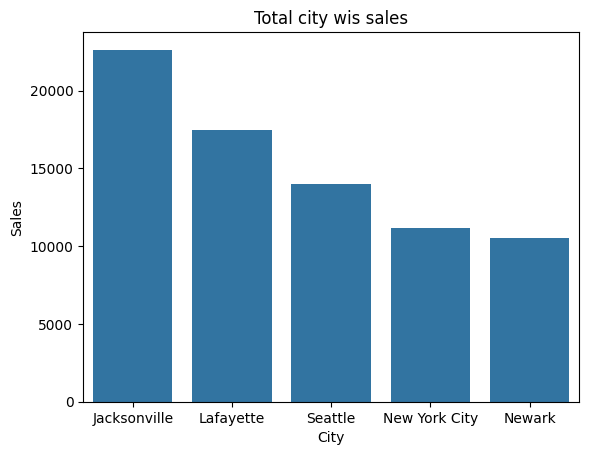

In [18]:
top10=df.sort_values(by= "Sales",ascending=False).head()

sns.barplot(data=top10, x="City", y="Sales")
plt.title("Total city wis sales")
plt.show()

##### **Insights:**

* **Jacksonville** is the top-performing city with the highest total sales.
* **Lafayette and Seattle City** show solid mid-level performance but are clearly below Jacksonville.
* **New York City and Newark** record the lowest sales among the listed cities, indicating weaker performance.


City
New York City    62013.8973
Los Angeles      30431.4267
Seattle          29121.6825
San Francisco    17466.1186
Detroit          13146.6935
Name: Profit, dtype: float64


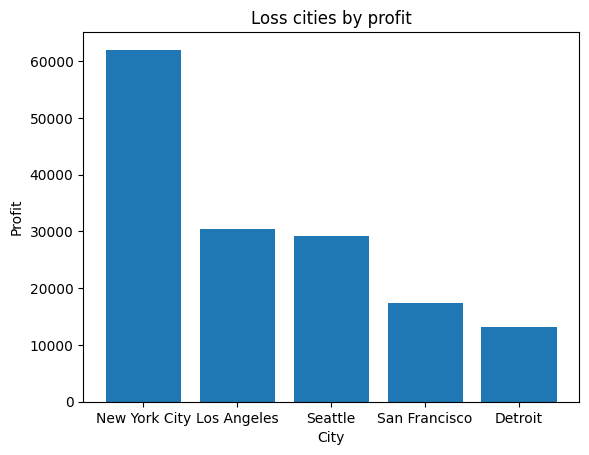

In [28]:
# plt.bar(loss_cities.index, loss_cities.values)

# loss_cities =

# plt.xticks(rotation=45)
# plt.xlabel("City")
# plt.ylabel("Profit")
# plt.title("top5 cites by profit")


# plt.show()
top5_cities=df.groupby("City")["Profit"].sum().sort_values(ascending=False)

loss_cities=top5_cities.head(5)
print(loss_cities)

plt.figure()

plt.bar(loss_cities.index, loss_cities.values)

plt.xlabel("City")
plt.ylabel("Profit")
plt.title("Loss cities by profit")

plt.show()

##### **Insights**

* **New York City** has the highest loss (negative profit), making it the most unprofitable city.
* **Los Angeles and Seattle** also show significant losses but much lower than New York City.
* **San Francisco and Detroit** have comparatively smaller losses, indicating relatively better performance among loss-making cities.


City
New York City    62013.8973
Los Angeles      30431.4267
Seattle          29121.6825
San Francisco    17466.1186
Detroit          13146.6935
Name: Profit, dtype: float64


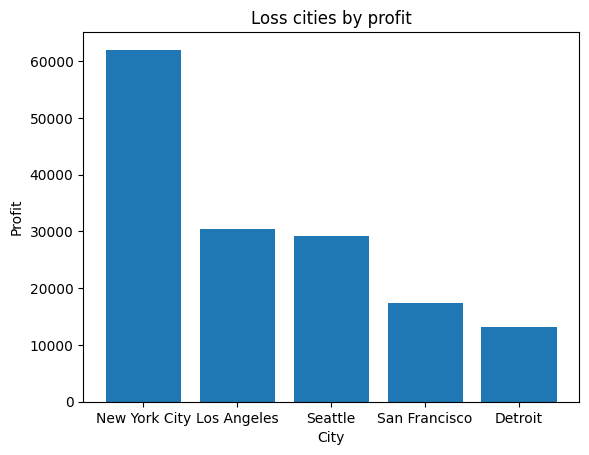

In [ ]:
top5_cities=df.groupby("City")["Profit"].sum().sort_values(ascending=False)

loss_cities=top5_cities.head(5)
print(loss_cities)

plt.figure()

plt.bar(loss_cities.index, loss_cities.values)

plt.xlabel("City")
plt.ylabel("Profit")
plt.title("Loss cities by profit")

plt.show()

##### **Insights**

* **New York City** is the biggest loss-making city by a large margin.
* **Los Angeles and Seattle** also face notable losses but significantly less than New York City.
* **San Francisco and Detroit** show the lowest losses, indicating relatively better control over profit decline.


In [ ]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

#### . The loss 5 cites 

City
New York City    62013.8973
Los Angeles      30431.4267
Seattle          29121.6825
San Francisco    17466.1186
Detroit          13146.6935
Name: Profit, dtype: float64


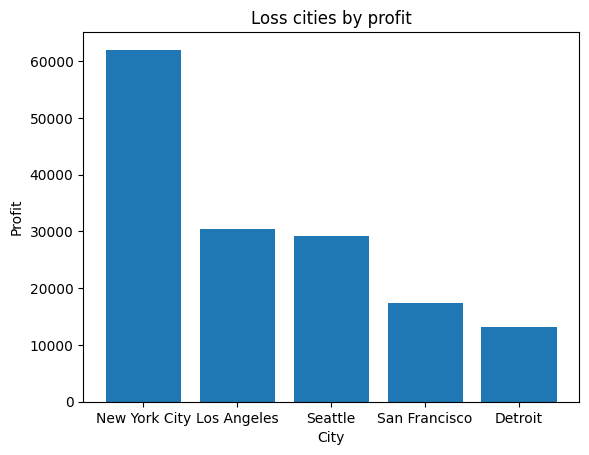

In [ ]:
top5_cities=df.groupby("City")["Profit"].sum().sort_values(ascending=False)

loss_cities=top5_cities.head(5)
print(loss_cities)

plt.figure()

plt.bar(loss_cities.index, loss_cities.values)

plt.xlabel("City")
plt.ylabel("Profit")
plt.title("Loss cities by profit")

plt.show()

##### **Insights**

- **Market Lead:** New York City is the primary profit driver, generating over $60,000—more than double the performance of any other city listed.

- **Secondary Tier:** Los Angeles and Seattle show consistent mid-range performance, both hovering around the $30,000 mark.

- **Significant Variance:** There is a sharp decline in profitability across the top five, with Detroit’s earnings being approximately 75% lower than New York City’s.

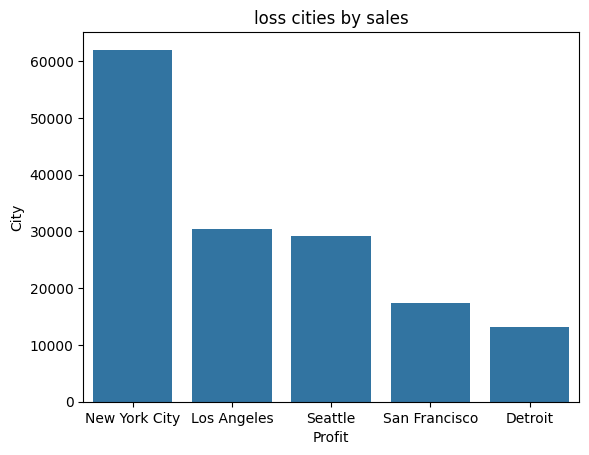

In [ ]:
sns.barplot(x=loss_cities.index, y=loss_cities.values)


plt.xlabel("Profit")
plt.ylabel("City")
plt.title("loss cities by sales")

plt.show()

##### **Insights**

- **Top Contributor:** New York City is the primary leader, generating over $60,000 in profit.

- **Secondary Market:** Los Angeles and Seattle show comparable performance, both contributing approximately $30,000.

- **Performance Gap:** There is a significant drop-off toward the bottom of the list, with Detroit earning roughly $13,000.

## **Final Conclusion**

- ####  Total Rows 9994
- ####  Total Columns 13

- ####  No missing/null values found
- ####  Duplicate rows were present and removed
- ####  Data types are correctly separated into:

## Categorical columns
- #### City, Region, Category, Segment, Ship Mode, Segment, Country, City, State, Region,Category, Sub-Category 

## Numerical columns 
- #### Postal Code, Sales, Quantity, Discount, Profit,object

## Outliers in Data set
- #### Some extreme high/low sales values exist

- ####  These outliers can affect average calculations

## City wise Analysis
- ####  Some cities contribute very high sales

- ####  These cities are key revenue drivers

- ####  Business should focus on these cities for marketing & stock availability